In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU Name:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA Version:",
        torch.version.cuda
    )

    print(
        "GPU Count:",
        torch.cuda.device_count()
    )

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version: 11.8
GPU Count: 1


In [10]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [11]:
DATASET_ROOT = Path(
    r"E:\Nordland Dataset\nordland-part-2020\nordland-part-2020"
)

SUMMER_DIR = (
    DATASET_ROOT /
    "summer"
)

WINTER_DIR = (
    DATASET_ROOT /
    "winter"
)

print("Summer Folder Exists:",
      SUMMER_DIR.exists())

print("Winter Folder Exists:",
      WINTER_DIR.exists())

Summer Folder Exists: True
Winter Folder Exists: True


In [12]:
summer_images = sorted(
    list(
        SUMMER_DIR.glob("*.png")
    )
)

winter_images = sorted(
    list(
        WINTER_DIR.glob("*.png")
    )
)

print(
    "Summer Images:",
    len(summer_images)
)

print(
    "Winter Images:",
    len(winter_images)
)

Summer Images: 1750
Winter Images: 1750


In [13]:
## Display Sample Image Paths

print("First Summer Image:")
print(summer_images[0])

print()

print("First Winter Image:")
print(winter_images[0])

First Summer Image:
E:\Nordland Dataset\nordland-part-2020\nordland-part-2020\summer\images-00251.png

First Winter Image:
E:\Nordland Dataset\nordland-part-2020\nordland-part-2020\winter\images-00251.png


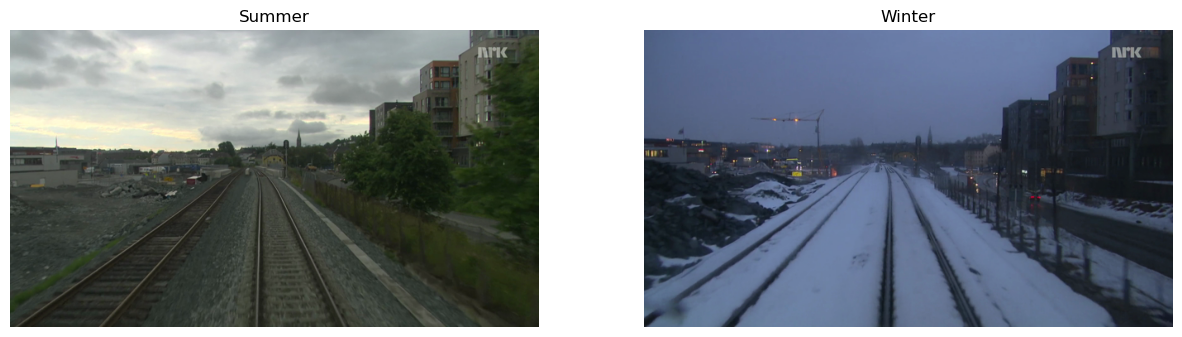

In [14]:
## Visualize Sample Pair

summer_sample = cv2.imread(
    str(summer_images[0])
)

winter_sample = cv2.imread(
    str(winter_images[0])
)

summer_sample = cv2.cvtColor(
    summer_sample,
    cv2.COLOR_BGR2RGB
)

winter_sample = cv2.cvtColor(
    winter_sample,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(summer_sample)
plt.title("Summer")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(winter_sample)
plt.title("Winter")
plt.axis("off")

plt.show()

In [15]:
## Verify LightGlue Installation

from lightglue import SuperPoint
from lightglue import LightGlue
from lightglue.utils import (
    load_image,
    rbd
)

print("LightGlue Loaded Successfully")

LightGlue Loaded Successfully


In [17]:
## Load SuperPoint Extractor

extractor = (
    SuperPoint(
        max_num_keypoints=4096
    )
    .eval()
    .to(device)
)

print("SuperPoint Loaded")

SuperPoint Loaded


In [18]:
## Load LightGlue Matcher
matcher = (
    LightGlue(
        features="superpoint"
    )
    .eval()
    .to(device)
)

print("LightGlue Loaded")

LightGlue Loaded


In [19]:
## Create Project Output Structure

OUTPUT_ROOT = Path("outputs")

MATCH_DIR = (
    OUTPUT_ROOT /
    "matches"
)

WARP_DIR = (
    OUTPUT_ROOT /
    "warped"
)

REPORT_DIR = (
    OUTPUT_ROOT /
    "reports"
)

MATCH_DIR.mkdir(
    parents=True,
    exist_ok=True
)

WARP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Folders Created")


Folders Created


In [20]:
print()

print("MATCH_DIR:")
print(MATCH_DIR)

print()

print("WARP_DIR:")
print(WARP_DIR)

print()

print("REPORT_DIR:")
print(REPORT_DIR)


MATCH_DIR:
outputs\matches

WARP_DIR:
outputs\warped

REPORT_DIR:
outputs\reports
